In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
sys.path.append('..')

# Import the database connector
from src.db_connector import fetch_data
from sklearn.model_selection import train_test_split

# 1. Fetch RAW data from the database to keep the original unscaled numbers
raw_df = fetch_data("SELECT * FROM e_commerce_dataset_e_comm")

# Basic data cleaning (must exactly match the preprocessing steps to maintain identical row count)
raw_df.dropna(subset=['Churn'], inplace=True)
raw_df['Tenure'] = pd.to_numeric(raw_df['Tenure'], errors='coerce')
raw_df['Tenure'].fillna(raw_df['Tenure'].median(), inplace=True)

# 2. Split Data (Ensure test_size and random_state are EXACTLY the same as in 02_Preprocessing)
X_raw = raw_df.drop('Churn', axis=1)
y_raw = raw_df['Churn']
_, X_test_raw, _, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

# 3. Load the scaled X_test data (this is required to feed into the Model)
X_test_scaled = pd.read_csv('../data/processed/X_test_preprocessed.csv')

# 4. Load your Winning Model (e.g., Tuned XGBoost)
best_model = joblib.load('../models/tuned_xgboost.pkl')

# 5. Generate predictions using the scaled data
churn_probabilities = best_model.predict_proba(X_test_scaled)[:, 1]

# 6. COMBINE PREDICTIONS with the RAW (Un-scaled) DATA
df = X_test_raw.copy()
df['Churn'] = y_test_raw
df['Churn_Probability'] = churn_probabilities

# Display the results to verify
print("Data Successfully Prepared for Business Insights!")
df[['Tenure', 'PreferredPaymentMode', 'Churn', 'Churn_Probability']].head()

Data Successfully Prepared for Business Insights!


C:\Users\Nicolaus Prima\AppData\Local\Temp\ipykernel_1764\3954089157.py:19: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  raw_df['Tenure'].fillna(raw_df['Tenure'].median(), inplace=True)


,Tenure,PreferredPaymentMode,Churn,Churn_Probability
4331,1.0,COD,1,0.108851
1988,15.0,Debit Card,0,0.627086
3443,13.0,Credit Card,0,0.033820
4559,5.0,Debit Card,0,0.091767
4898,13.0,Debit Card,0,0.814564


## 1. Financial Impact

Total Customers Lost: 185 people
Estimated Revenue Lost: Rp 92,500,000


C:\Users\Nicolaus Prima\AppData\Local\Temp\ipykernel_1764\560309065.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Reds')


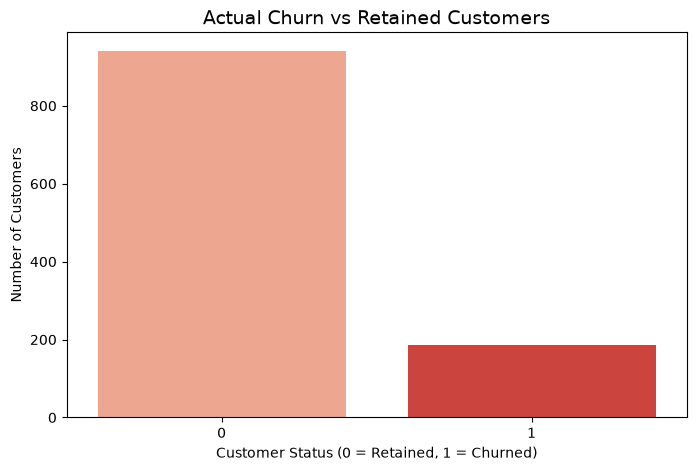

In [ ]:
# Let's assume an average customer brings Rp 500,000 in revenue per month
average_revenue = 500000 
total_churners = df[df['Churn'] == 1].shape[0]
revenue_lost = total_churners * average_revenue

print(f"Total Customers Lost: {total_churners} people")
print(f"Estimated Revenue Lost: Rp {revenue_lost:,}")

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Churn', palette='Reds')
plt.title('Actual Churn vs Retained Customers', fontsize=14)
plt.xlabel('Customer Status (0 = Retained, 1 = Churned)')
plt.ylabel('Number of Customers')
plt.show()

## 2. Feature Importance

C:\Users\Nicolaus Prima\AppData\Local\Temp\ipykernel_1764\3710011783.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Tenure_Group', y='Churn', errorbar=None, palette='magma')


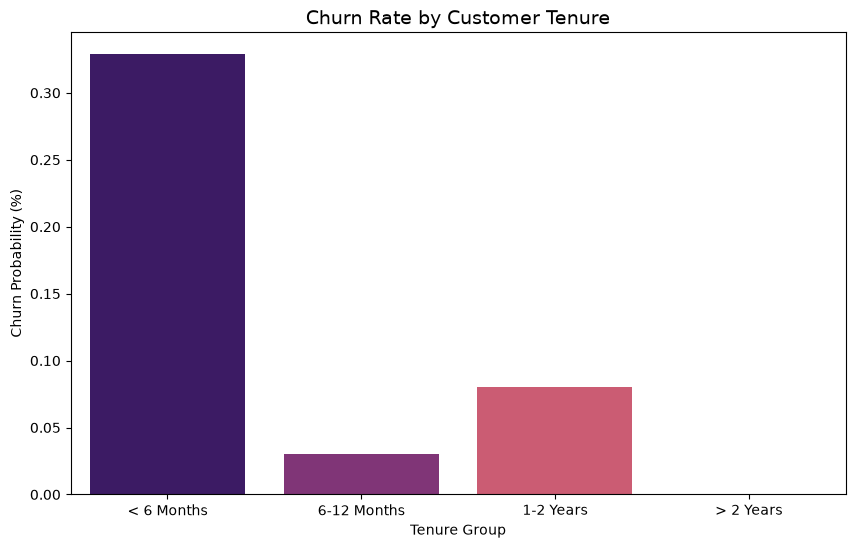

Business Insight: Customers in their first 6 months have the highest risk of churning. We need a strong 'Welcome Bonus' retention program.


In [3]:
plt.figure(figsize=(10, 6))

# We group the Tenure into logical business months
df['Tenure_Group'] = pd.cut(df['Tenure'], bins=[-1, 6, 12, 24, 100], labels=['< 6 Months', '6-12 Months', '1-2 Years', '> 2 Years'])

# Plotting the Churn Rate (Percentage) per group
sns.barplot(data=df, x='Tenure_Group', y='Churn', errorbar=None, palette='magma')

plt.title('Churn Rate by Customer Tenure', fontsize=14)
plt.xlabel('Tenure Group')
plt.ylabel('Churn Probability (%)')
plt.show()

print("Business Insight: Customers in their first 6 months have the highest risk of churning. We need a strong 'Welcome Bonus' retention program.")

## 3. Customer Profilling

C:\Users\Nicolaus Prima\AppData\Local\Temp\ipykernel_1764\613952788.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Risk_Level', order=['Low Risk', 'Medium Risk', 'High Risk'], palette='coolwarm')


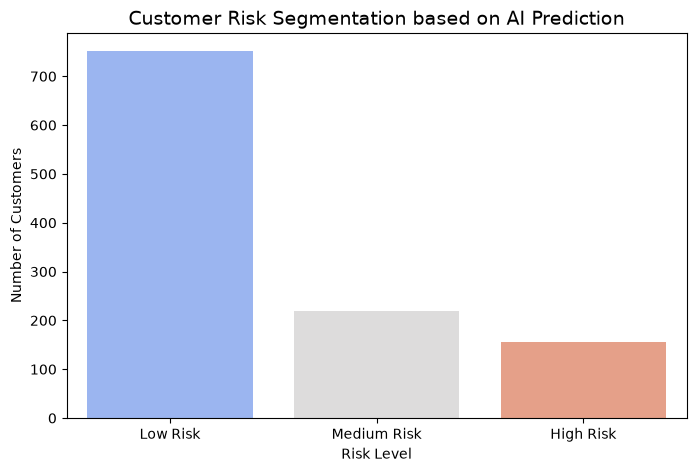

Actionable Recommendation:
- High Risk: Call immediately and offer 20% discount.
- Medium Risk: Send personalized product recommendation emails.
- Low Risk: Do nothing, save the marketing budget.


In [4]:
# Create Risk Segments based on Model's Probability
def assign_risk(prob):
    if prob >= 0.70:
        return 'High Risk'
    elif prob >= 0.40:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['Risk_Level'] = df['Churn_Probability'].apply(assign_risk)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Risk_Level', order=['Low Risk', 'Medium Risk', 'High Risk'], palette='coolwarm')
plt.title('Customer Risk Segmentation based on AI Prediction', fontsize=14)
plt.xlabel('Risk Level')
plt.ylabel('Number of Customers')
plt.show()

print("Actionable Recommendation:")
print("- High Risk: Call immediately and offer 20% discount.")
print("- Medium Risk: Send personalized product recommendation emails.")
print("- Low Risk: Do nothing, save the marketing budget.")

## 4. Cost-Benefit Analysis

Cost of Blind Marketing (Promo to All)          : Rp 56,300,000
Cost of Smart Targeted Marketing (High Risk Only): Rp 7,800,000
Total Marketing Budget SAVED using the Model     : Rp 48,500,000


C:\Users\Nicolaus Prima\AppData\Local\Temp\ipykernel_1764\3291357031.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=strategies, y=costs, palette='Greens_r')


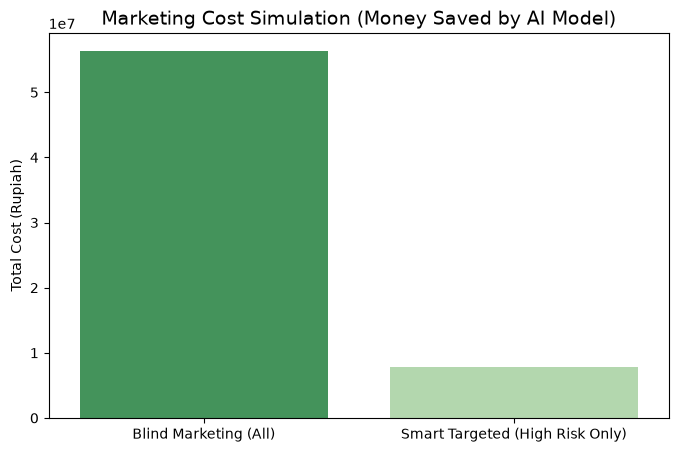

In [5]:
# Scenario: We give a Rp 50,000 discount promo to prevent churn
cost_per_promo = 50000

# Strategy A: Blindly give promo to ALL customers
cost_strategy_A = len(df) * cost_per_promo

# Strategy B: Give promo ONLY to 'High Risk' customers identified by the Model
high_risk_customers = len(df[df['Risk_Level'] == 'High Risk'])
cost_strategy_B = high_risk_customers * cost_per_promo

money_saved = cost_strategy_A - cost_strategy_B

print(f"Cost of Blind Marketing (Promo to All)          : Rp {cost_strategy_A:,}")
print(f"Cost of Smart Targeted Marketing (High Risk Only): Rp {cost_strategy_B:,}")
print(f"Total Marketing Budget SAVED using the Model     : Rp {money_saved:,}")

# Visualization
strategies = ['Blind Marketing (All)', 'Smart Targeted (High Risk Only)']
costs = [cost_strategy_A, cost_strategy_B]

plt.figure(figsize=(8, 5))
sns.barplot(x=strategies, y=costs, palette='Greens_r')
plt.title('Marketing Cost Simulation (Money Saved by AI Model)', fontsize=14)
plt.ylabel('Total Cost (Rupiah)')
plt.show()


## 5. Export Data

In [7]:
import os
import pandas as pd

# 1. Create a dedicated folder for Power BI exports if it doesn't exist
os.makedirs('../data/powerbi_exports', exist_ok=True)

# 2. Select the EXACT columns needed to build the perfect Power BI Dashboard
cols_for_powerbi = [
    'CustomerID',
    'Tenure',
    'Complain',
    'CityTier',
    'Gender',
    'MaritalStatus',
    'PreferredPaymentMode',
    'OrderAmountHikeFromlastYear', 
    'DaySinceLastOrder',
    'Churn',
    'Churn_Probability',
    'Risk_Level'
]

# 3. Create the final dataset containing only the necessary columns
powerbi_df = df[cols_for_powerbi].copy()

# 4. Clean up any 'Null' values inherited from the raw database
# We fill missing numbers with 0, and missing text with 'Unknown'
for col in powerbi_df.columns:
    if powerbi_df[col].dtype == 'object':
        powerbi_df[col].fillna('Unknown', inplace=True)
    else:
        powerbi_df[col].fillna(0, inplace=True)

# 5. Define the export file path
export_path = '../data/powerbi_exports/churn_predictions_powerbi.csv'

# 6. Export to CSV (index=False ensures no unnecessary row numbers are saved)
powerbi_df.to_csv(export_path, index=False)

print("EXPORT SUCCESSFUL")
print("The data is clean and fully optimized for the Power BI Dashboard!")
print(f"File saved at: {export_path}")


EXPORT SUCCESSFUL
The data is clean and fully optimized for the Power BI Dashboard!
File saved at: ../data/powerbi_exports/churn_predictions_powerbi.csv


C:\Users\Nicolaus Prima\AppData\Local\Temp\ipykernel_1764\2761320548.py:32: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  powerbi_df[col].fillna(0, inplace=True)
